In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt 
from matplotlib.patches import Patch
import time


In [2]:
# -------------------------
# 1) Tous les subsets non vides
# -------------------------
def all_subsets(p):
    subsets = []
    for k in range(1, p+1):
        subsets += list(itertools.combinations(range(p), k))
    return subsets

# -------------------------
# 2) Tirage uniforme de U
# -------------------------
def sample_U(subsets):
    idx = np.random.randint(len(subsets))
    return subsets[idx], idx

# -------------------------
# 3) Pick-Freeze
# -------------------------
def pick_freeze(X, Xp, U):
    XU = Xp.copy()
    for i in U:
        XU[i] = X[i]
    return XU

# -------------------------
# 4) Calcul M^{-1}s pour un subset U
# = somme des s_v pour v ⊆ U
# -------------------------
def Minv_s(s, subsets, U):
    total = 0
    for j, v in enumerate(subsets):
        if set(v).issubset(U):
            total += s[j]
    return total

# -------------------------
# 5) Gradient
# -------------------------
def gradient(s, subsets, U, Y, YU, m):
    q = len(s)
    g = np.zeros(q)
    
    a = Y - m
    Minv = Minv_s(s, subsets, U)
    scalar = a * Minv - (YU - m)
    
    for j, v in enumerate(subsets):
        if set(v).issubset(U):
            g[j] = a * scalar
            
    return g

# -------------------------
# 6) Mirror update
# -------------------------
def mirror_update(s, g, eta):
    s_new = s * np.exp(-eta * g)
    return s_new / np.sum(s_new)

# -------------------------
# 7) Algorithme principal
# -------------------------
def run_algorithm(f, p, N, sample_X, eta0=0.3):
    
    subsets = all_subsets(p)
    q = len(subsets)
    
    # Initialisation uniforme
    s = np.ones(q) / q
    m = 0
    
    for n in range(N):
        
        eta = eta0 / np.sqrt(n+1)
        
        # --- Distribution choisie ---
        X = sample_X(p)
        Xp = sample_X(p)
        
        # Sample subset
        U, idxU = sample_U(subsets)
        
        # Pick-Freeze
        Y = f(X)
        XU = pick_freeze(X, Xp, U)
        YU = f(XU)
        
        g = gradient(s, subsets, set(U), Y, YU, m)
        s = mirror_update(s, g, eta)
        
        m = m + (Y - m) / (n+1)
    
    return s, subsets

def get_first_order(s, subsets, p):
    first = np.zeros(p)
    for j, U in enumerate(subsets):
        if len(U) == 1:
            i = U[0]
            first[i] = s[j]
    return first

def get_total_order(s, subsets, p):
    total = np.zeros(p)
    for j, U in enumerate(subsets):
        for i in U:
            total[i] += s[j]
    return total

In [3]:
def sobol_pf_first_order(f, p, N, sample_X):
    Y_vals = np.zeros(N)
    Y_freeze = np.zeros((p, N))
    
    for n in range(N):
        X = sample_X(p)
        Xp = sample_X(p)
        
        Y = f(X)
        Y_vals[n] = Y
        
        for i in range(p):
            XU = Xp.copy()
            XU[i] = X[i]   # freeze variable i
            Y_freeze[i, n] = f(XU)
    
    VarY = np.var(Y_vals, ddof=1)
    
    S = np.zeros(p)
    for i in range(p):
        cov = np.cov(Y_vals, Y_freeze[i], ddof=1)[0,1]
        S[i] = cov / VarY
        
    return S

def sobol_pf_total_order(f, p, N, sample_X):
    Y_vals = np.zeros(N)
    Y_freeze = np.zeros((p, N))
    
    for n in range(N):
        X = sample_X(p)
        Xp = sample_X(p)
        
        Y = f(X)
        Y_vals[n] = Y
        
        for i in range(p):
            XU = X.copy()
            XU[i] = Xp[i]   # replace variable i
            Y_freeze[i, n] = f(XU)
    
    VarY = np.var(Y_vals, ddof=1)
    
    ST = np.zeros(p)
    for i in range(p):
        ST[i] = np.mean((Y_vals - Y_freeze[i])**2) / (2 * VarY)
        
    return ST



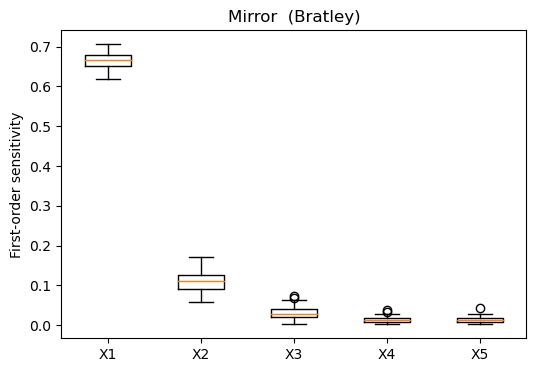

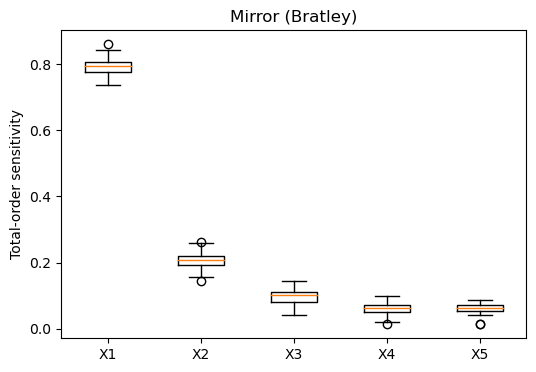

In [4]:
def f_bratley(x):
    s = 0
    prod = 1
    for i in range(len(x)):
        prod *= x[i]
        s += (-1)**(i+1) * prod
    return s


p = 5
N = 5000
MC = 50

def sample_uniform(p):
    return np.random.rand(p)

first_results = []
total_results = []

start = time.time()
for _ in range(MC):
    
    s_hat, subsets = run_algorithm(
        f_bratley,
        p,
        N,
        sample_X=sample_uniform, eta0=10.0
    )
    
    first = get_first_order(s_hat, subsets, p)
    total = get_total_order(s_hat, subsets, p)
    
    first_results.append(first)
    total_results.append(total)
mirror_time = time.time() - start
first_results = np.array(first_results)
total_results = np.array(total_results)


first_pf = []
total_pf = []

start = time.time()
for _ in range(MC):
    first = sobol_pf_first_order(f_bratley, p, N, sample_uniform)
    total = sobol_pf_total_order(f_bratley, p, N, sample_uniform)
    
    first_pf.append(first)
    total_pf.append(total)

pf_time = time.time() - start
first_pf = np.array(first_pf)
total_pf = np.array(total_pf)


plt.figure(figsize=(6,4))
plt.boxplot(first_results, labels=[f"X{i+1}" for i in range(p)])
plt.ylabel("First-order sensitivity")
plt.title("Mirror  (Bratley)")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(total_results, labels=[f"X{i+1}" for i in range(p)])
plt.ylabel("Total-order sensitivity")
plt.title("Mirror (Bratley)")
plt.show()


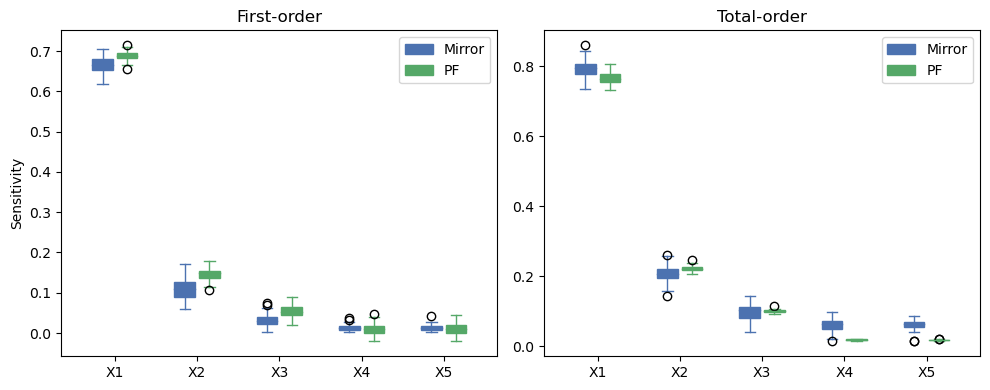


Total time over 50 runs:
Mirror: 8.89 s
PF: 8.61 s
Speed ratio PF / Mirror = 0.97
First-order means
X1  Mirror=0.6642  PF=0.6878
X2  Mirror=0.1104  PF=0.1465
X3  Mirror=0.0317  PF=0.0542
X4  Mirror=0.0138  PF=0.0093
X5  Mirror=0.0136  PF=0.0097

Total-order means
X1  Mirror=0.7919  PF=0.7653
X2  Mirror=0.2074  PF=0.2220
X3  Mirror=0.0968  PF=0.0997
X4  Mirror=0.0618  PF=0.0182
X5  Mirror=0.0613  PF=0.0177


In [5]:
color_mirror = "#4C72B0"   # bleu
color_pf = "#55A868"       # vert

fig, axes = plt.subplots(1, 2, figsize=(10,4))
legend_elements = [
    Patch(facecolor=color_mirror, edgecolor=color_mirror, label='Mirror'),
    Patch(facecolor=color_pf, edgecolor=color_pf, label='PF')
]

# ======================
# FIRST-ORDER
# ======================
ax = axes[0]

for i in range(p):
    # Mirror
    bp1 = ax.boxplot(first_results[:, i],
                     positions=[i+1-0.15],
                     widths=0.25,
                     patch_artist=True)

    # PF
    bp2 = ax.boxplot(first_pf[:, i],
                     positions=[i+1+0.15],
                     widths=0.25,
                     patch_artist=True)

    # couleur Mirror
    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp1[element], color=color_mirror)
    bp1['boxes'][0].set_facecolor(color_mirror)

    # couleur PF
    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp2[element], color=color_pf)
    bp2['boxes'][0].set_facecolor(color_pf)

ax.set_xticks(range(1, p+1))
ax.set_xticklabels([f"X{i+1}" for i in range(p)])
axes[0].legend(handles=legend_elements, loc='upper right')
ax.set_title("First-order")
ax.set_ylabel("Sensitivity")

# ======================
# TOTAL-ORDER
# ======================
ax = axes[1]

for i in range(p):
    bp1 = ax.boxplot(total_results[:, i],
                     positions=[i+1-0.15],
                     widths=0.25,
                     patch_artist=True)

    bp2 = ax.boxplot(total_pf[:, i],
                     positions=[i+1+0.15],
                     widths=0.25,
                     patch_artist=True)

    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp1[element], color=color_mirror)
    bp1['boxes'][0].set_facecolor(color_mirror)

    for element in ['boxes','whiskers','caps','medians']:
        plt.setp(bp2[element], color=color_pf)
    bp2['boxes'][0].set_facecolor(color_pf)

ax.set_xticks(range(1, p+1))
axes[1].legend(handles=legend_elements, loc='upper right')
ax.set_xticklabels([f"X{i+1}" for i in range(p)])
ax.set_title("Total-order")

plt.tight_layout()
plt.show()


print(f"\nTotal time over {MC} runs:")
print(f"Mirror: {mirror_time:.2f} s")
print(f"PF: {pf_time:.2f} s")
print(f"Speed ratio PF / Mirror = {pf_time/mirror_time:.2f}")

print("First-order means")
for i in range(p):
    print(f"X{i+1}  Mirror={first_results[:,i].mean():.4f}  PF={first_pf[:,i].mean():.4f}")

print("\nTotal-order means")
for i in range(p):
    print(f"X{i+1}  Mirror={total_results[:,i].mean():.4f}  PF={total_pf[:,i].mean():.4f}")


Parameters: {'N': 20000, 'R': 400, 'beta1': 1.0, 'beta2': 2.0, 'gamma': 1.0, 'eta0': 1.0, 'stepsize': 'harmonic', 'average': 'simple'}
s* = [0.16666667 0.66666667 0.16666667]
Mean of sqrt(N)(sbar - s*): [-1.01193426  3.59505364 -2.58311937]
Cov of sqrt(N)(sbar - s*):
 [[ 206.18412269  -83.81655635 -122.36756634]
 [ -83.81655635  222.85220657 -139.03565022]
 [-122.36756634 -139.03565022  261.40321656]]


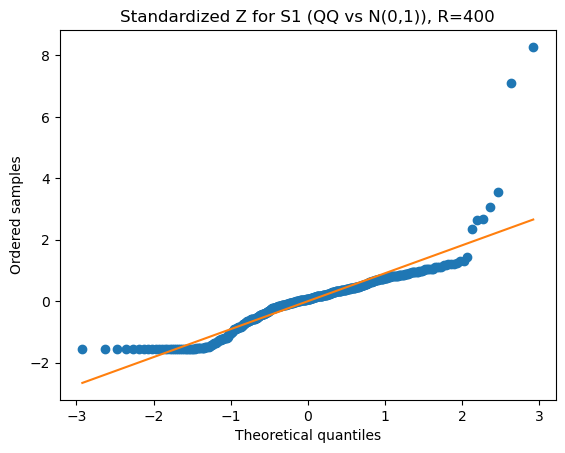

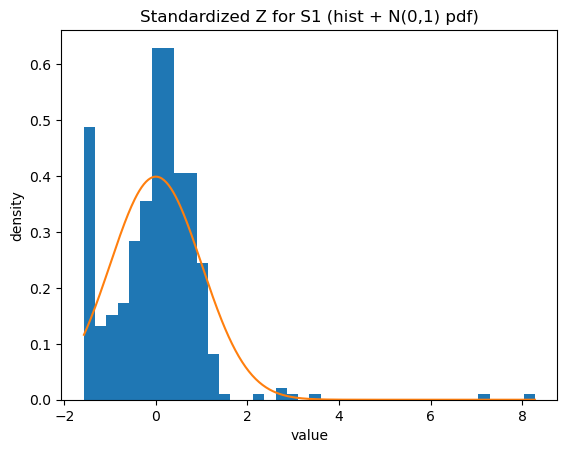

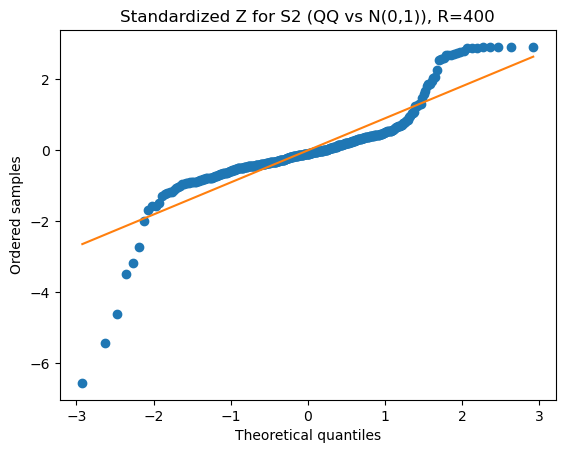

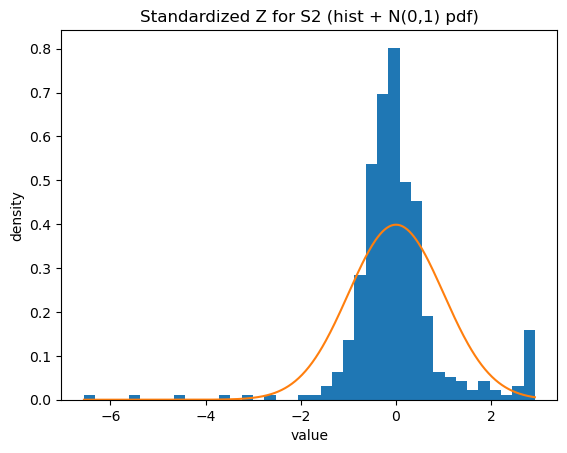

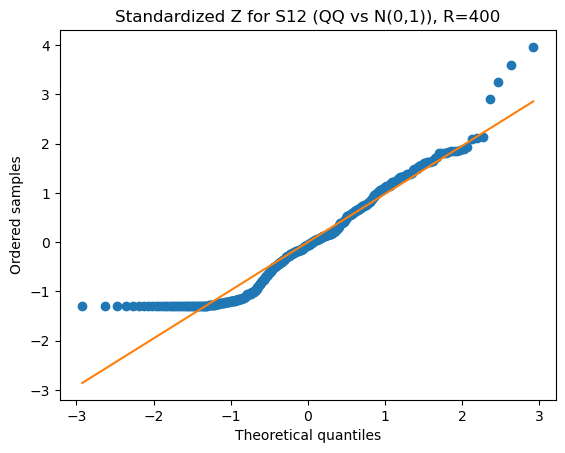

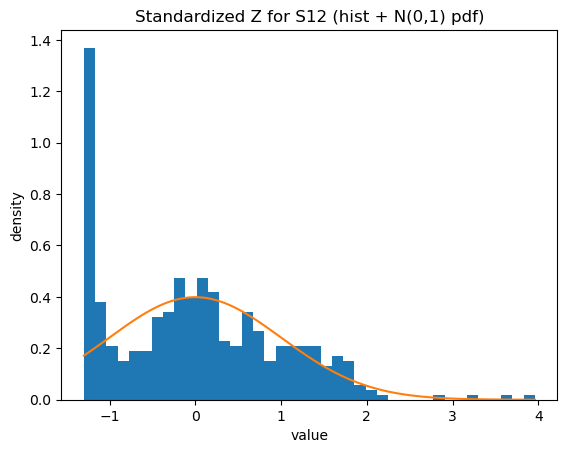

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# 1) Black-box model f and true Sobol for p=2
# -----------------------------
def f(X, beta1=1.0, beta2=2.0, gamma=1.0):
    """
    X: array shape (..., 2)
    Y = beta1*X1 + beta2*X2 + gamma*X1*X2
    """
    x1 = X[..., 0]
    x2 = X[..., 1]
    return beta1 * x1 + beta2 * x2 + gamma * x1 * x2

def true_sobol(beta1=1.0, beta2=2.0, gamma=1.0):
    """
    For X1,X2 iid N(0,1), Y=beta1 X1 + beta2 X2 + gamma X1 X2:
    S1 = beta1^2 / (beta1^2+beta2^2+gamma^2)
    S2 = beta2^2 / (beta1^2+beta2^2+gamma^2)
    S12 = gamma^2 / (beta1^2+beta2^2+gamma^2)
    """
    V0 = beta1**2 + beta2**2 + gamma**2
    return np.array([beta1**2 / V0, beta2**2 / V0, gamma**2 / V0])

# -----------------------------
# 2) Algorithm 1 (Pick-Freeze Mirror) for p=2, uniform a
#    Exactly as in the paper:
#      m_{n+1} = m_n + (Y_{n+1}-m_n)/(n+1)
#      grad_hat_{n+1}(s) = (Y-m_n) M^{-1}_{U,:} * ((Y-m_n)[M^{-1}s]_U - (Y^U-m_n))
#      s_{n+1} ∝ s_n * exp(-eta_{n+1} * grad_hat)
# -----------------------------

# U in { {1}, {2}, {1,2} } with uniform prob
# Order: 0->{1}, 1->{2}, 2->{12}
M_inv_rows = np.array([
    [1.0, 0.0, 0.0],  # U={1}
    [0.0, 1.0, 0.0],  # U={2}
    [1.0, 1.0, 1.0],  # U={12}
])

def sample_pick_freeze_pair(rng, beta1, beta2, gamma):
    """
    Sample (X, X') iid N(0, I_2), sample U ~ uniform on 3 subsets,
    build X^(U) (pick-freeze), return (Y, YU, U_index).
    """
    X = rng.standard_normal(size=2)
    Xp = rng.standard_normal(size=2)
    U = rng.integers(0, 3)  # 0,1,2 equally likely

    if U == 0:      # {1}: keep X1, freeze X2 -> X2'
        Xu = np.array([X[0], Xp[1]])
    elif U == 1:    # {2}: freeze X1 -> X1', keep X2
        Xu = np.array([Xp[0], X[1]])
    else:           # {1,2}: keep both
        Xu = X

    Y = f(X, beta1, beta2, gamma)
    Yu = f(Xu, beta1, beta2, gamma)
    return Y, Yu, U

def mirror_update(s, grad, eta):
    """
    Entropic mirror step:
      s_new = s * exp(-eta * grad) / || s * exp(-eta*grad) ||_1
    """
    z = s * np.exp(-eta * grad)
    z_sum = np.sum(z)
    # numerical safeguard
    if not np.isfinite(z_sum) or z_sum <= 0:
        z = np.maximum(z, 1e-300)
        z_sum = np.sum(z)
    return z / z_sum

def run_pf_mirror(
    N,
    beta1=1.0, beta2=2.0, gamma=1.0,
    eta0=1.0, stepsize="harmonic",   # "harmonic": eta_n = eta0/(n+1), "sqrt": eta0/sqrt(n+1)
    average="simple",               # "simple": (1/N) sum s_n ; "weighted": sum eta_{k} s_k / sum eta_{k}
    seed=0
):
    """
    Returns:
      s_path: (N+1,3) with s_0,...,s_N
      sbar: averaged estimator at time N (per chosen averaging)
    """
    rng = np.random.default_rng(seed)

    # init (paper): uniform over non-empty subsets => q=3 here
    s = np.array([1/3, 1/3, 1/3], dtype=float)
    m = 0.0

    s_path = np.zeros((N + 1, 3), dtype=float)
    s_path[0] = s

    # averaging accumulators
    if average == "simple":
        acc = np.zeros(3, dtype=float)
        acc_w = 0.0
    elif average == "weighted":
        acc = np.zeros(3, dtype=float)
        acc_w = 0.0
    else:
        raise ValueError("average must be 'simple' or 'weighted'.")

    for n in range(0, N):  # step uses (n+1)
        # sample (Y_{n+1}, Y^U_{n+1}, U_{n+1})
        Y, Yu, U = sample_pick_freeze_pair(rng, beta1, beta2, gamma)

        # stepsize eta_{n+1}
        if stepsize == "harmonic":
            eta = eta0 / (n + 1)
        elif stepsize == "sqrt":
            eta = eta0 / np.sqrt(n + 1)
        else:
            raise ValueError("stepsize must be 'harmonic' or 'sqrt'.")

        # grad estimator uses m_n (paper) and s_n
        row = M_inv_rows[U]                    # M^{-1}_{U,:}
        sigma_U = float(row @ s)               # [M^{-1} s]_U
        Ym = Y - m
        scalar = Ym * sigma_U - (Yu - m)
        grad_hat = Ym * row * scalar           # vector in R^3

        # mirror descent update
        s = mirror_update(s, grad_hat, eta)

        # update mean m_{n+1} using Y_{n+1} (paper)
        m = m + (Y - m) / (n + 1)

        s_path[n + 1] = s

        # update averaging (uses s_k with k = n+1)
        if average == "simple":
            acc += s
            acc_w += 1.0
        else:  # weighted
            acc += eta * s
            acc_w += eta

    sbar = acc / acc_w
    return s_path, sbar

# -----------------------------
# 3) Monte Carlo TCL check: many replications
# -----------------------------
def clt_experiment(
    N=5000,
    R=500,  # number of replications
    beta1=1.0, beta2=2.0, gamma=1.0,
    eta0=1.0,
    stepsize="harmonic",
    average="simple",
    base_seed=12345
):
    s_star = true_sobol(beta1, beta2, gamma)

    Z = np.zeros((R, 3), dtype=float)  # sqrt(N) * (sbar - s*)
    Sbar = np.zeros((R, 3), dtype=float)

    for r in range(R):
        _, sbar = run_pf_mirror(
            N=N, beta1=beta1, beta2=beta2, gamma=gamma,
            eta0=eta0, stepsize=stepsize, average=average,
            seed=base_seed + r
        )
        Sbar[r] = sbar
        Z[r] = np.sqrt(N) * (sbar - s_star)

    # sample mean/cov of scaled errors
    meanZ = Z.mean(axis=0)
    covZ = np.cov(Z.T, ddof=1)

    print("Parameters:", dict(N=N, R=R, beta1=beta1, beta2=beta2, gamma=gamma,
                             eta0=eta0, stepsize=stepsize, average=average))
    print("s* =", s_star)
    print("Mean of sqrt(N)(sbar - s*):", meanZ)
    print("Cov of sqrt(N)(sbar - s*):\n", covZ)

    return Z, Sbar, s_star, meanZ, covZ

def qqplot_1d(samples, title):
    (osm, osr), (slope, intercept, r) = stats.probplot(samples, dist="norm")
    plt.figure()
    plt.plot(osm, osr, marker="o", linestyle="None")
    plt.plot(osm, slope*osm + intercept)
    plt.title(f"{title} (QQ vs N(0,1)), R={len(samples)}")
    plt.xlabel("Theoretical quantiles")
    plt.ylabel("Ordered samples")

def hist_1d(samples, title):
    plt.figure()
    plt.hist(samples, bins=40, density=True)
    x = np.linspace(samples.min(), samples.max(), 400)
    plt.plot(x, stats.norm.pdf(x))
    plt.title(f"{title} (hist + N(0,1) pdf)")
    plt.xlabel("value")
    plt.ylabel("density")

# -----------------------------
# 4) Run a default check
# -----------------------------
if __name__ == "__main__":
    # Choose parameters with interior optimum (beta1,beta2,gamma all nonzero)
    beta1, beta2, gamma = 1.0, 2.0, 1.0

    # For CLT, harmonic stepsize eta_n ~ c/n is usually the right regime.
    # Use averaging="simple" or "weighted" (paper's Cesaro uses weights eta).
    Z, Sbar, s_star, meanZ, covZ = clt_experiment(
        N=20000,
        R=400,
        beta1=beta1, beta2=beta2, gamma=gamma,
        eta0=1.0,
        stepsize="harmonic",
        average="simple",
        base_seed=2026
    )

    # Check 1D marginals: standardize using sample mean/cov
    # (So QQ/hist are on roughly N(0,1) scale if joint CLT holds.)
    std = np.sqrt(np.diag(covZ))
    Zstd = (Z - meanZ) / std

    labels = ["S1", "S2", "S12"]
    for j in range(3):
        qqplot_1d(Zstd[:, j], f"Standardized Z for {labels[j]}")
        hist_1d(Zstd[:, j], f"Standardized Z for {labels[j]}")

    plt.show()

In [9]:
import numpy as np

# ---------- True Sobol for p=2 with interaction ----------
def true_sobol(beta1, beta2, gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    return np.array([beta1**2 / V0, beta2**2 / V0, gamma**2 / V0])

# ---------- Theoretical H for uniform a (p=2) ----------
def H_uniform_p2(beta1, beta2, gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    return (V0 / 4.0) * np.array([[2.0, 1.0, 1.0],
                                 [1.0, 2.0, 1.0],
                                 [1.0, 1.0, 1.0]])

# ---------- Closed-form E[A1^2], E[A2^2] from previous derivation ----------
def EA1_sq(beta1, beta2, gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    b1, b2, g = beta1, beta2, gamma
    num = (
        2*b1**6*b2**2 + 6*b1**6*g**2 + 5*b1**4*b2**4 + 22*b1**4*b2**2*g**2 + 9*b1**4*g**4
        + 4*b1**2*b2**6 + 24*b1**2*b2**4*g**2 + 32*b1**2*b2**2*g**4 + 12*b1**2*g**6
        + b2**8 + 8*b2**6*g**2 + 16*b2**4*g**4 + 12*b2**2*g**6 + 3*g**8
    )
    return num / (V0**2)

def EA2_sq(beta1, beta2, gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    b1, b2, g = beta1, beta2, gamma
    num = (
        b1**8 + 4*b1**6*b2**2 + 8*b1**6*g**2 + 5*b1**4*b2**4 + 24*b1**4*b2**2*g**2 + 16*b1**4*g**4
        + 2*b1**2*b2**6 + 22*b1**2*b2**4*g**2 + 32*b1**2*b2**2*g**4 + 12*b1**2*g**6
        + 6*b2**6*g**2 + 9*b2**4*g**4 + 12*b2**2*g**6 + 3*g**8
    )
    return num / (V0**2)

# ---------- Theoretical Sigma_xi for uniform a (p=2): diag((1/3)E[A1^2], (1/3)E[A2^2], 0) ----------
def Sigma_xi_uniform_p2(beta1, beta2, gamma):
    return (1.0/3.0) * np.diag([EA1_sq(beta1, beta2, gamma),
                               EA2_sq(beta1, beta2, gamma),
                               0.0])

# ---------- Project to theta=(s1,s2), with s = J theta + const, where J = [[1,0],[0,1],[-1,-1]] ----------
J = np.array([[ 1.0,  0.0],
              [ 0.0,  1.0],
              [-1.0, -1.0]])

def V_theta_theoretical(beta1, beta2, gamma):
    H = H_uniform_p2(beta1, beta2, gamma)
    Sig = Sigma_xi_uniform_p2(beta1, beta2, gamma)

    # Effective Hessian and noise covariance in theta-coordinates
    H_theta = J.T @ H @ J
    Sig_theta = J.T @ Sig @ J

    V_theta = np.linalg.inv(H_theta) @ Sig_theta @ np.linalg.inv(H_theta)
    return V_theta

# ---------- Comparison helper ----------
def compare_empirical_to_theory(Z, beta1, beta2, gamma):
    """
    Z: array (R,3) = sqrt(N) * (sbar - s*)
    compares empirical covariance of (Z1,Z2) to theoretical V_theta
    """
    Z_theta = Z[:, :2]  # (delta s1, delta s2)
    cov_emp = np.cov(Z_theta.T, ddof=1)
    cov_th = V_theta_theoretical(beta1, beta2, gamma)

    print("Empirical cov (theta=(s1,s2)):\n", cov_emp)
    print("Theoretical V_theta:\n", cov_th)
    print("Abs diff:\n", np.abs(cov_emp - cov_th))
    print("Rel diff (|emp-th|/|th|):\n", np.abs(cov_emp - cov_th) / (np.abs(cov_th) + 1e-12))

# -------------------------
# Example usage (assumes you already ran clt_experiment and got Z)
# -------------------------
beta1,beta2,gamma = 1.0, 2.0, 1.0
Z, Sbar, s_star, meanZ, covZ = clt_experiment(
     N=20000, R=400, beta1=beta1, beta2=beta2, gamma=gamma,
  eta0=1.0, stepsize="harmonic", average="simple", base_seed=2026
)
compare_empirical_to_theory(Z, beta1, beta2, gamma)

Parameters: {'N': 20000, 'R': 400, 'beta1': 1.0, 'beta2': 2.0, 'gamma': 1.0, 'eta0': 1.0, 'stepsize': 'harmonic', 'average': 'simple'}
s* = [0.16666667 0.66666667 0.16666667]
Mean of sqrt(N)(sbar - s*): [-1.01193426  3.59505364 -2.58311937]
Cov of sqrt(N)(sbar - s*):
 [[ 206.18412269  -83.81655635 -122.36756634]
 [ -83.81655635  222.85220657 -139.03565022]
 [-122.36756634 -139.03565022  261.40321656]]
Empirical cov (theta=(s1,s2)):
 [[206.18412269 -83.81655635]
 [-83.81655635 222.85220657]]
Theoretical V_theta:
 [[8.41975309 0.        ]
 [0.         5.82716049]]
Abs diff:
 [[197.7643696   83.81655635]
 [ 83.81655635 217.02504608]]
Rel diff (|emp-th|/|th|):
 [[2.34881436e+01 8.38165563e+13]
 [8.38165563e+13 3.72437049e+01]]


In [10]:
import numpy as np
from numpy.linalg import inv
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------
# Model and true Sobol (p=2)
# -----------------------------
def f(X, beta1, beta2, gamma):
    x1, x2 = X[...,0], X[...,1]
    return beta1*x1 + beta2*x2 + gamma*x1*x2

def s_star(beta1, beta2, gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    return np.array([beta1**2/V0, beta2**2/V0, gamma**2/V0])

# -----------------------------
# p=2, order: {1},{2},{12}
# M^{-1} rows
# -----------------------------
M_inv_rows = np.array([
    [1.,0.,0.],  # U={1}
    [0.,1.,0.],  # U={2}
    [1.,1.,1.],  # U={12}
])

def sample_Y_Yu_U(rng, beta1, beta2, gamma):
    X  = rng.standard_normal(2)
    Xp = rng.standard_normal(2)
    U = rng.integers(0,3)  # uniform on {1},{2},{12}

    if U == 0:      # {1}
        Xu = np.array([X[0], Xp[1]])
    elif U == 1:    # {2}
        Xu = np.array([Xp[0], X[1]])
    else:           # {12}
        Xu = X

    Y  = f(X,  beta1, beta2, gamma)
    Yu = f(Xu, beta1, beta2, gamma)
    return Y, Yu, U

# -----------------------------
# Stable entropic mirror update
# s_new = softmax(log s - eta*grad)
# -----------------------------
def mirror_update_logsafe(s, grad, eta):
    logw = np.log(s) - eta * grad
    m = np.max(logw)
    w = np.exp(logw - m)
    w_sum = np.sum(w)
    return w / w_sum

# -----------------------------
# Run Algorithm 1 exactly (unknown mean m_n), but stable mirror
# PR average after burn-in
# eta_n = eta0/(n+1)
# -----------------------------
def run_algo(N, beta1, beta2, gamma, eta0=0.05, burn_in=2000, seed=0):
    rng = np.random.default_rng(seed)
    s = np.array([1/3,1/3,1/3], dtype=float)
    m = 0.0

    acc = np.zeros(3)
    acc_w = 0

    for n in range(N):  # corresponds to step n+1 in paper
        Y, Yu, U = sample_Y_Yu_U(rng, beta1, beta2, gamma)

        eta = eta0 / (n+1)  # harmonic

        row = M_inv_rows[U]
        sigmaU = float(row @ s)  # [M^{-1}s]_U
        Ym = Y - m
        scalar = Ym * sigmaU - (Yu - m)
        grad_hat = Ym * row * scalar  # Eq (21) in paper :contentReference[oaicite:1]{index=1}

        s = mirror_update_logsafe(s, grad_hat, eta)  # Eq (19)/(22) 

        # update mean with Y (use m_n in grad, as paper says) :contentReference[oaicite:3]{index=3}
        m = m + (Y - m) / (n+1)

        if n+1 > burn_in:
            acc += s
            acc_w += 1

    sbar = acc/acc_w
    return sbar

# -----------------------------
# Theoretical H for uniform a, p=2 (Appendix B) :contentReference[oaicite:4]{index=4}
# -----------------------------
def H_uniform(beta1,beta2,gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    return (V0/4.) * np.array([[2.,1.,1.],[1.,2.,1.],[1.,1.,1.]])

# -----------------------------
# Closed-form E[A1^2], E[A2^2] (from our derivation)
# + MC check to validate the formula before using it
# -----------------------------
def EA1_sq_closed(beta1,beta2,gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    b1,b2,g = beta1,beta2,gamma
    num = (
        2*b1**6*b2**2 + 6*b1**6*g**2 + 5*b1**4*b2**4 + 22*b1**4*b2**2*g**2 + 9*b1**4*g**4
        + 4*b1**2*b2**6 + 24*b1**2*b2**4*g**2 + 32*b1**2*b2**2*g**4 + 12*b1**2*g**6
        + b2**8 + 8*b2**6*g**2 + 16*b2**4*g**4 + 12*b2**2*g**6 + 3*g**8
    )
    return num/(V0**2)

def EA2_sq_closed(beta1,beta2,gamma):
    V0 = beta1**2 + beta2**2 + gamma**2
    b1,b2,g = beta1,beta2,gamma
    num = (
        b1**8 + 4*b1**6*b2**2 + 8*b1**6*g**2 + 5*b1**4*b2**4 + 24*b1**4*b2**2*g**2 + 16*b1**4*g**4
        + 2*b1**2*b2**6 + 22*b1**2*b2**4*g**2 + 32*b1**2*b2**2*g**4 + 12*b1**2*g**6
        + 6*b2**6*g**2 + 9*b2**4*g**4 + 12*b2**2*g**6 + 3*g**8
    )
    return num/(V0**2)

def EA_sq_mc(beta1,beta2,gamma, M=2_000_00, seed=0):
    rng = np.random.default_rng(seed)
    ss = s_star(beta1,beta2,gamma)
    s1, s2 = ss[0], ss[1]

    A1 = np.empty(M)
    A2 = np.empty(M)

    for k in range(M):
        # build one PF pair once, then use it for U=1 and U=2 separately
        X  = rng.standard_normal(2)
        Xp = rng.standard_normal(2)

        Y  = f(X,  beta1,beta2,gamma)
        Y1 = f(np.array([X[0],  Xp[1]]), beta1,beta2,gamma)  # U={1}
        Y2 = f(np.array([Xp[0], X[1]]),  beta1,beta2,gamma)  # U={2}

        A1[k] = Y*(Y*s1 - Y1)
        A2[k] = Y*(Y*s2 - Y2)

    return float(np.mean(A1**2)), float(np.mean(A2**2))

def Sigma_xi_theory(beta1,beta2,gamma):
    # uniform on Upsilon => P(U=1)=P(U=2)=P(U=12)=1/3
    return (1/3.)*np.diag([EA1_sq_closed(beta1,beta2,gamma),
                           EA2_sq_closed(beta1,beta2,gamma),
                           0.0])

# work in theta=(s1,s2), with s12=1-s1-s2
J = np.array([[1.,0.],[0.,1.],[-1.,-1.]])

def V_theta_theory(beta1,beta2,gamma):
    H = H_uniform(beta1,beta2,gamma)
    Sig = Sigma_xi_theory(beta1,beta2,gamma)
    Ht = J.T@H@J
    Sigt = J.T@Sig@J
    return inv(Ht)@Sigt@inv(Ht)

# -----------------------------
# CLT experiment and comparison
# -----------------------------
def clt_check(N=200_000, R=300, beta1=1., beta2=2., gamma=1., eta0=0.05, burn_in=5000, seed0=1234):
    ss = s_star(beta1,beta2,gamma)
    Z = np.zeros((R,2))  # only (s1,s2)

    for r in range(R):
        sbar = run_algo(N, beta1,beta2,gamma, eta0=eta0, burn_in=burn_in, seed=seed0+r)
        theta_bar = sbar[:2]
        theta_star = ss[:2]
        Z[r] = np.sqrt(N) * (theta_bar - theta_star)

    cov_emp = np.cov(Z.T, ddof=1)
    cov_th  = V_theta_theory(beta1,beta2,gamma)

    print("Empirical cov (theta):\n", cov_emp)
    print("Theory cov (theta):\n", cov_th)
    print("Rel error:\n", np.abs(cov_emp-cov_th)/(np.abs(cov_th)+1e-12))

    # whiten using theoretical covariance
    L = np.linalg.cholesky(cov_th)
    Zwhite = np.linalg.solve(L, Z.T).T  # ~ N(0,I) if CLT matches

    for j,name in enumerate(["theta1","theta2"]):
        (osm, osr), (slope, intercept, _) = stats.probplot(Zwhite[:,j], dist="norm")
        plt.figure()
        plt.plot(osm, osr, "o")
        plt.plot(osm, slope*osm + intercept)
        plt.title(f"QQ whitened {name} vs N(0,1)")

    plt.show()
    return Z, cov_emp, cov_th

# -----------------------------
# 1) sanity check of EA^2 formulas (do this once!)
# -----------------------------
if __name__ == "__main__":
    beta1,beta2,gamma = 1.,2.,1.
    mc1, mc2 = EA_sq_mc(beta1,beta2,gamma, M=200_000, seed=0)
    print("E[A1^2] closed vs MC:", EA1_sq_closed(beta1,beta2,gamma), mc1)
    print("E[A2^2] closed vs MC:", EA2_sq_closed(beta1,beta2,gamma), mc2)

    # 2) CLT check
    clt_check(N=200_000, R=200, beta1=beta1,beta2=beta2,gamma=gamma, eta0=0.05, burn_in=10_000)

E[A1^2] closed vs MC: 56.833333333333336 57.63291665606506
E[A2^2] closed vs MC: 39.333333333333336 38.558510957836205


KeyboardInterrupt: 